# Pendulum: SME vs LSE confidence regions

Three-panel figure: parameter plane at $T_\mathrm{left}$, diameter vs $T$, parameter plane at $T_\mathrm{right}$.

Run with working directory **yingying** (this folder is self-contained).


In [33]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This folder is self-contained: run with cwd = yingying/
HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

# After editing local *.py helpers, clear cached modules (or restart kernel).
for _name in (
    "plot_regions",
    "lse_confidence",
    "sme_pendulum_polytope",
    "set_membership_non_analytic",
    "non_analytic_dynamics",
    "pendulum_dynamics",
    "pendulum_dynamics_active_explore",
    "lse_pend",
    "pendulum_RLS",
):
    sys.modules.pop(_name, None)

from pendulum_dynamics import SimplePendulumDynamics, system_parameters
from pendulum_dynamics_active_explore import run_active_learning
from lse_pend import theta_star_values
from plot_regions import (
    compute_diameter_curves,
    make_figure,
    regions_at_T,
    save_figure,
    sme_set_diameter,
)

m, l, k = system_parameters()
theta_star = theta_star_values(m, l)
print("theta* =", theta_star)


theta* = [ 2. 40.]


In [34]:
disturbance = "trunc_guass"
parameter_dist = [0.0, 1.0, 1.0]
mult_w = [1.0, 1.0]
c_input = "trunc_guass"
parameter_input = [0.0, 1.0, 1.0]
mult_u = [1.0]

w_max = 0.01
bu = 1.0
seed_u, seed_w = 131, 331

T_left, T_right = 20, 100
T_collect = T_right
T_curve = list(range(T_left, T_right + 1, 5))

lse_kw = dict(
    lam=1e-8,
    L=w_max,
    S=float(np.linalg.norm(theta_star)),
    delta=0.1,
    sigma=1.0,
)

active_cfg = dict(
    H=10, alpha=0.3, beta=0.01, bu=bu, n_plan_samples=5000, warmup=10,
    distr=disturbance, param_w=tuple(parameter_dist), mult_w=tuple(mult_w),
)
warmup = active_cfg["warmup"]  # for T <= warmup, active LSE uses passive data (no active episodes yet)

In [35]:
print("Passive trajectory...")
t0 = time.perf_counter()
pend = SimplePendulumDynamics(c_input, disturbance)
pend.get_trajectory_3(
    [0.0, 0.0], T_collect, seed_u, seed_w,
    parameter_input, mult_u, parameter_dist, mult_w, bu,
)
y_passive = np.asarray(pend.b_s_list, dtype=float)
phi_passive = np.asarray(pend.phi_s_u_list, dtype=float)
print(f"  {len(y_passive)} samples, wall {time.perf_counter() - t0:.2f}s")

print("Active learning...")
t0 = time.perf_counter()
res_active = run_active_learning(
    np.array([0.0, 0.0]), m, l, T_budget=T_collect, seed_w=seed_w,
    rng=np.random.default_rng(2026), **active_cfg,
)
if res_active.planning_failed:
    raise RuntimeError(res_active.planning_fail_message)
y_active = np.asarray(res_active.y_delta_omega, dtype=float)
phi_active = np.asarray(res_active.psi_rows, dtype=float)
print(f"  {len(y_active)} samples, wall {time.perf_counter() - t0:.2f}s")

Passive trajectory...
  100 samples, wall 0.00s
Active learning...
  100 samples, wall 0.06s


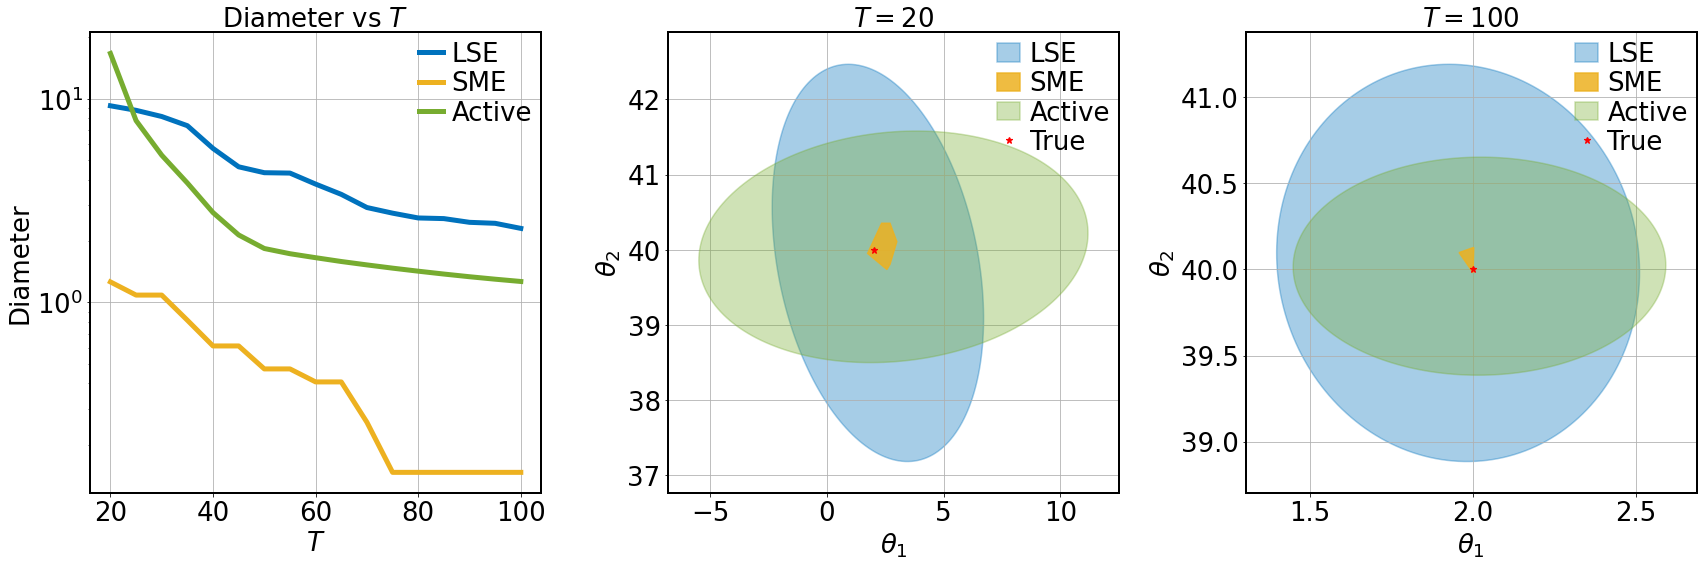

Saved: c:\Research\Cursor_dir\real-analytic-nonlinear-sys-id-main\pendulum sys id\yingying\figures\pendulum_sme_lse_figure.png
At T=20: SME diameter = 1.260


In [36]:
sme_left, passive_left, active_left = regions_at_T(
    T_left, phi_passive, y_passive, phi_active, y_active,
    w_max=w_max, lse_kw=lse_kw, warmup=warmup,
)
sme_right, passive_right, active_right = regions_at_T(
    T_right, phi_passive, y_passive, phi_active, y_active,
    w_max=w_max, lse_kw=lse_kw, warmup=warmup,
)
sme_d, lse_p_d, lse_a_d = compute_diameter_curves(
    T_curve, phi_passive, y_passive, phi_active, y_active,
    w_max=w_max, lse_kw=lse_kw, warmup=warmup,
)

fig, _ = make_figure(
    T_left, T_right,
    sme_left=sme_left, passive_left=passive_left, active_left=active_left,
    sme_right=sme_right, passive_right=passive_right, active_right=active_right,
    T_curve=T_curve, sme_d=sme_d, lse_p_d=lse_p_d, lse_a_d=lse_a_d,
    theta_star=theta_star,
)

out_path = ROOT / "yingying" / "figures" / "pendulum_sme_lse_figure.png"
save_figure(fig, out_path)
plt.show()
print("Saved:", out_path)
print(f"At T={T_left}: SME diameter = {sme_set_diameter(y_passive[:T_left], phi_passive[:T_left], w_max, vertices=sme_left):.3f}")